In [1]:
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid")

In [3]:
def filterCalls2(speciesDF, heteroDF):
    df1 = speciesDF.copy()
    df2 = heteroDF.copy()

    goodGenotypes = ['0|1', '1|1', '1|0', '0/1', '1/1', '1/0']
    sex_chroms = ['chrX_hap1', 'chrY_hap1']

    # Clean key columns
    for df in [df1, df2]:
        df["GENOTYPE_clean"] = df["GENOTYPE"].astype(str).str.strip()
        df["CHROM_clean"] = df["CHROM"].astype(str).str.strip()
        df["ID_clean"] = df["ID"].astype(str).str.strip()

    # Keep good genotype rows or sex chromosome rows
    df1_mask = (
        df1["GENOTYPE_clean"].isin(goodGenotypes) |
        df1["CHROM_clean"].isin(sex_chroms)
    )

    df2_mask = (
        df2["GENOTYPE_clean"].isin(goodGenotypes) |
        df2["CHROM_clean"].isin(sex_chroms)
    )

    speciesSpecificDF = df1.loc[df1_mask].copy()
    heterozygousDF = df2.loc[df2_mask].copy()

    # Find overlapping IDs after filtering
    overlap = (
        set(speciesSpecificDF["ID_clean"]) &
        set(heterozygousDF["ID_clean"])
    )

    # Clean classification columns
    shared_clean = (
        heterozygousDF["Shared_Classification"]
        .astype(str)
        .str.strip()
        .str.upper()
    )

    fixed_clean = (
        speciesSpecificDF["Fixed"]
        .astype(str)
        .str.strip()
        .str.upper()
    )

    # For heterozygousDF:
    # keep non-Species rows, or Species rows with overlapping ID
    het_mask = (
        shared_clean.ne("SPECIES") |
        heterozygousDF["ID_clean"].isin(overlap)
    )

    # For speciesSpecificDF:
    # keep Fixed != NO rows, or Fixed == NO rows with overlapping ID
    ss_mask = (
        fixed_clean.ne("NO") |
        speciesSpecificDF["ID_clean"].isin(overlap)
    )

    finalSpeciesSpecificDF = speciesSpecificDF.loc[ss_mask].copy()
    finalHeterozygousDF = heterozygousDF.loc[het_mask].copy()

    helper_cols = ["GENOTYPE_clean", "CHROM_clean", "ID_clean"]

    finalSpeciesSpecificDF = finalSpeciesSpecificDF.drop(
        columns=[c for c in helper_cols if c in finalSpeciesSpecificDF.columns]
    )

    finalHeterozygousDF = finalHeterozygousDF.drop(
        columns=[c for c in helper_cols if c in finalHeterozygousDF.columns]
    )

    return finalSpeciesSpecificDF, finalHeterozygousDF

In [4]:
#Species specific PAV Dataframes
PPY_PAVDF_unfiltered1 = pd.read_csv("/Users/loftum/Desktop/PersonalProjects/TE_Leaves/Publication/2026_SexChromosome_Removal/PAV_Human_SharedInsertions_Polymoprhic_andSpeciesSpecific_Dataframes/AG05252_PPY_PAVhuman_filtered_06292025.csv", low_memory=False)
PAB_PAVDF_unfiltered1 = pd.read_csv("/Users/loftum/Desktop/PersonalProjects/TE_Leaves/Publication/2026_SexChromosome_Removal/PAV_Human_SharedInsertions_Polymoprhic_andSpeciesSpecific_Dataframes/AG06213_PAB_PAVhuman_filtered_06292025.csv", low_memory=False)
PTR_PAVDF_unfiltered1 = pd.read_csv("/Users/loftum/Desktop/PersonalProjects/TE_Leaves/Publication/2026_SexChromosome_Removal/PAV_Human_SharedInsertions_Polymoprhic_andSpeciesSpecific_Dataframes/AG18354_PTR_PAVhuman_filtered_06292025.csv", low_memory=False)
GGO_PAVDF_unfiltered1 = pd.read_csv("/Users/loftum/Desktop/PersonalProjects/TE_Leaves/Publication/2026_SexChromosome_Removal/PAV_Human_SharedInsertions_Polymoprhic_andSpeciesSpecific_Dataframes/Jim_GGO_PAVhuman_filtered_06292025.csv",low_memory=False)
PPA_PAVDF_unfiltered1 = pd.read_csv("/Users/loftum/Desktop/PersonalProjects/TE_Leaves/Publication/2026_SexChromosome_Removal/PAV_Human_SharedInsertions_Polymoprhic_andSpeciesSpecific_Dataframes/PR00251_PPA_PAVhuman_filtered_06292025.csv",low_memory=False)
PPY_PAVDF_unfiltered1['GENOTYPE']= PPY_PAVDF_unfiltered1['GENOTYPE'].astype(str)
PAB_PAVDF_unfiltered1['GENOTYPE']= PAB_PAVDF_unfiltered1['GENOTYPE'].astype(str)
PTR_PAVDF_unfiltered1['GENOTYPE']= PTR_PAVDF_unfiltered1['GENOTYPE'].astype(str)
GGO_PAVDF_unfiltered1['GENOTYPE']= GGO_PAVDF_unfiltered1['GENOTYPE'].astype(str)
PPA_PAVDF_unfiltered1['GENOTYPE']= PPA_PAVDF_unfiltered1['GENOTYPE'].astype(str)

#Polymorphic SS and LS Dataframes
PPY_PAVDF_SSunfiltered = pd.read_csv("/Users/loftum/Desktop/PersonalProjects/TE_Leaves/Publication/2026_SexChromosome_Removal/PAV_Human_SharedInsertions_Polymoprhic_andSpeciesSpecific_Dataframes/PonPyg_SpeciesSpecific_and_Shared_Polymorphic_08M-16D-2025Y.csv")
PAB_PAVDF_SSunfiltered = pd.read_csv("/Users/loftum/Desktop/PersonalProjects/TE_Leaves/Publication/2026_SexChromosome_Removal/PAV_Human_SharedInsertions_Polymoprhic_andSpeciesSpecific_Dataframes/PonAbe_SpeciesSpecific_and_Shared_Polymorphic_08M-16D-2025Y.csv")
PTR_PAVDF_SSunfiltered = pd.read_csv("/Users/loftum/Desktop/PersonalProjects/TE_Leaves/Publication/2026_SexChromosome_Removal/PAV_Human_SharedInsertions_Polymoprhic_andSpeciesSpecific_Dataframes/PanTro_SpeciesSpecific_and_Shared_Polymorphic_08M-16D-2025Y.csv")
GGO_PAVDF_SSunfiltered = pd.read_csv("/Users/loftum/Desktop/PersonalProjects/TE_Leaves/Publication/2026_SexChromosome_Removal/PAV_Human_SharedInsertions_Polymoprhic_andSpeciesSpecific_Dataframes/GorGor_SpeciesSpecific_and_Shared_Polymorphic_08M-16D-2025Y.csv")
PPA_PAVDF_SSunfiltered = pd.read_csv("/Users/loftum/Desktop/PersonalProjects/TE_Leaves/Publication/2026_SexChromosome_Removal/PAV_Human_SharedInsertions_Polymoprhic_andSpeciesSpecific_Dataframes/PanPan_SpeciesSpecific_and_Shared_Polymorphic_08M-16D-2025Y.csv")

###################################################################
#FILTER
PPY_PAVDF_unfilteredSSonly, PPY_PAVDF_unfilteredSSLS = filterCalls2(PPY_PAVDF_unfiltered1, PPY_PAVDF_SSunfiltered)
PAB_PAVDF_unfilteredSSonly, PAB_PAVDF_unfilteredSSLS = filterCalls2(PAB_PAVDF_unfiltered1, PAB_PAVDF_SSunfiltered)
PTR_PAVDF_unfilteredSSonly, PTR_PAVDF_unfilteredSSLS = filterCalls2(PTR_PAVDF_unfiltered1, PTR_PAVDF_SSunfiltered)
GGO_PAVDF_unfilteredSSonly, GGO_PAVDF_unfilteredSSLS = filterCalls2(GGO_PAVDF_unfiltered1, GGO_PAVDF_SSunfiltered)
PPA_PAVDF_unfilteredSSonly, PPA_PAVDF_unfilteredSSLS = filterCalls2(PPA_PAVDF_unfiltered1, PPA_PAVDF_SSunfiltered)

##################################################
#Species specific
PPY_PAVDF_sexFiltered = PPY_PAVDF_unfilteredSSonly[~PPY_PAVDF_unfilteredSSonly['CHROM'].isin(['chrX_hap1','chrY_hap1'])].copy()
PAB_PAVDF_sexFiltered = PAB_PAVDF_unfilteredSSonly[~PAB_PAVDF_unfilteredSSonly['CHROM'].isin(['chrX_hap1','chrY_hap1'])].copy()
PTR_PAVDF_sexFiltered = PTR_PAVDF_unfilteredSSonly[~PTR_PAVDF_unfilteredSSonly['CHROM'].isin(['chrX_hap1','chrY_hap1'])].copy()
GGO_PAVDF_sexFiltered = GGO_PAVDF_unfilteredSSonly[~GGO_PAVDF_unfilteredSSonly['CHROM'].isin(['chrX_hap1','chrY_hap1'])].copy()
PPA_PAVDF_sexFiltered = PPA_PAVDF_unfilteredSSonly[~PPA_PAVDF_unfilteredSSonly['CHROM'].isin(['chrX_hap1','chrY_hap1'])].copy()

#Species specific heterozygous
het_genotypes = ["0|1", "1|0", "0/1", "1/0"]
PPY_Het_noSex_PAVDF = PPY_PAVDF_sexFiltered[
    PPY_PAVDF_sexFiltered["GENOTYPE"].astype(str).isin(het_genotypes)
].copy()
PAB_Het_noSex_PAVDF = PAB_PAVDF_sexFiltered[
    PAB_PAVDF_sexFiltered["GENOTYPE"].astype(str).isin(het_genotypes)
].copy()
PTR_Het_noSex_PAVDF = PTR_PAVDF_sexFiltered[
    PTR_PAVDF_sexFiltered["GENOTYPE"].astype(str).isin(het_genotypes)
].copy()
GGO_Het_noSex_PAVDF = GGO_PAVDF_sexFiltered[
    GGO_PAVDF_sexFiltered["GENOTYPE"].astype(str).isin(het_genotypes)
].copy()
PPA_Het_noSex_PAVDF = PPA_PAVDF_sexFiltered[
    PPA_PAVDF_sexFiltered["GENOTYPE"].astype(str).isin(het_genotypes)
].copy()

###################################################
#heterozygous calls (species specific and lineage specific)
PPY_PAVDF_SSsexFiltered = PPY_PAVDF_unfilteredSSLS[~PPY_PAVDF_unfilteredSSLS['CHROM'].isin(['chrX_hap1','chrY_hap1'])].copy()
PAB_PAVDF_SSsexFiltered = PAB_PAVDF_unfilteredSSLS[~PAB_PAVDF_unfilteredSSLS['CHROM'].isin(['chrX_hap1','chrY_hap1'])].copy()
PTR_PAVDF_SSsexFiltered = PTR_PAVDF_unfilteredSSLS[~PTR_PAVDF_unfilteredSSLS['CHROM'].isin(['chrX_hap1','chrY_hap1'])].copy()
GGO_PAVDF_SSsexFiltered = GGO_PAVDF_unfilteredSSLS[~GGO_PAVDF_unfilteredSSLS['CHROM'].isin(['chrX_hap1','chrY_hap1'])].copy()
PPA_PAVDF_SSsexFiltered = PPA_PAVDF_unfilteredSSLS[~PPA_PAVDF_unfilteredSSLS['CHROM'].isin(['chrX_hap1','chrY_hap1'])].copy()

In [5]:
#PPY_PAVDF_unfilteredSS.set_index("ID").to_csv("/Users/loftum/Desktop/PersonalProjects/TE_Leaves/Publication/2026_SexChromosome_Removal/deliverables/Filtered_PAV_Callsets/AG05252_PPY_PAV_SpeciesSpecific_05252026.csv")
#PPY_PAVDF_unfiltered1.set_index("ID").to_csv("/Users/loftum/Desktop/PersonalProjects/TE_Leaves/Publication/2026_SexChromosome_Removal/deliverables/Filtered_PAV_Callsets/AG05252_PPY_PAV_heterozygous_SSandLS_05252026.csv")

#PAB_PAVDF_unfilteredSS.set_index("ID").to_csv("/Users/loftum/Desktop/PersonalProjects/TE_Leaves/Publication/2026_SexChromosome_Removal/deliverables/Filtered_PAV_Callsets/AG06213_PAB_PAV_SpeciesSpecific_05252026.csv")
#PAB_PAVDF_unfiltered1.set_index("ID").to_csv("/Users/loftum/Desktop/PersonalProjects/TE_Leaves/Publication/2026_SexChromosome_Removal/deliverables/Filtered_PAV_Callsets/AG06213_PAB_PAV_heterozygous_SSandLS_05252026.csv")

#PTR_PAVDF_unfilteredSS.set_index("ID").to_csv("/Users/loftum/Desktop/PersonalProjects/TE_Leaves/Publication/2026_SexChromosome_Removal/deliverables/Filtered_PAV_Callsets/AG18354_PTR_PAV_SpeciesSpecific_05252026.csv")
#PTR_PAVDF_unfiltered1.set_index("ID").to_csv("/Users/loftum/Desktop/PersonalProjects/TE_Leaves/Publication/2026_SexChromosome_Removal/deliverables/Filtered_PAV_Callsets/AG18354_PTR_PAV_heterozygous_SSandLS_05252026.csv")

#GGO_PAVDF_unfilteredSS.set_index("ID").to_csv("/Users/loftum/Desktop/PersonalProjects/TE_Leaves/Publication/2026_SexChromosome_Removal/deliverables/Filtered_PAV_Callsets/Jim_GGO_PAV_SpeciesSpecific_05252026.csv")
#GGO_PAVDF_unfiltered1.set_index("ID").to_csv("/Users/loftum/Desktop/PersonalProjects/TE_Leaves/Publication/2026_SexChromosome_Removal/deliverables/Filtered_PAV_Callsets/Jim_GGO_PAV_heterozygous_SSandLS_05252026.csv")

#PPA_PAVDF_unfilteredSS.set_index("ID").to_csv("/Users/loftum/Desktop/PersonalProjects/TE_Leaves/Publication/2026_SexChromosome_Removal/deliverables/Filtered_PAV_Callsets/PR00251_PPA_PAV_SpeciesSpecific_05252026.csv")
#PPA_PAVDF_unfiltered1.set_index("ID").to_csv("/Users/loftum/Desktop/PersonalProjects/TE_Leaves/Publication/2026_SexChromosome_Removal/deliverables/Filtered_PAV_Callsets/PR00251_PPA_PAV__heterozygous_SSandLS_05252026.csv")

In [6]:
groupColors = {'ss_color': '#008080',
'ls_color':"#80cbc4",
'ils_color':"#e9c46a"}

In [7]:
speciesOrderList=['PTR', 'PPA', 'GGO', 'PAB', 'PPY']

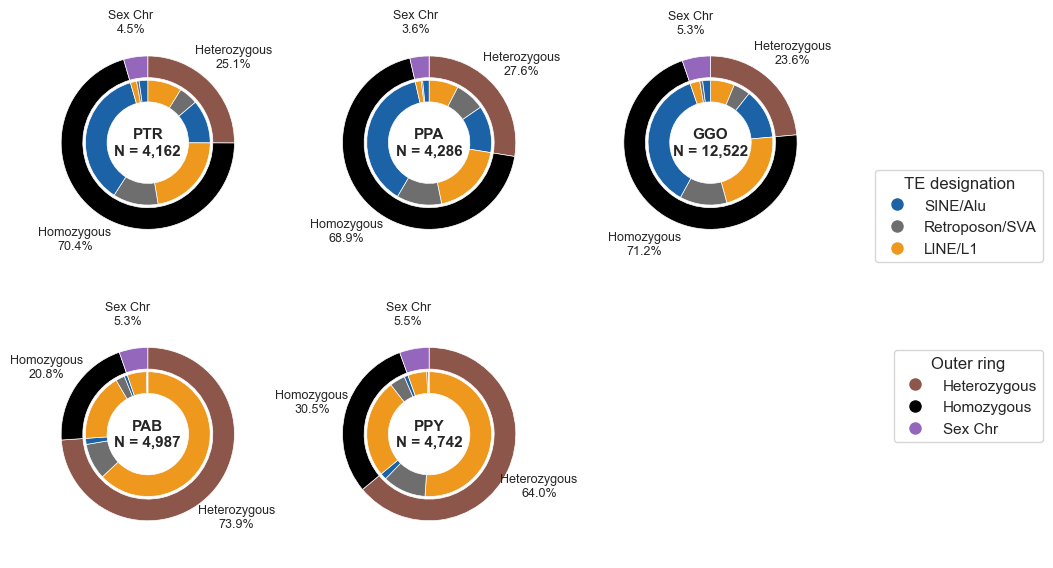

In [44]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

te_colors = {
    "SINE/Alu": "#1B62A6",
    "Retroposon/SVA": "#6E6E6E",
    "LINE/L1": "#EE981E"
}

dfs = {
    "PPY": PPY_PAVDF_unfilteredSSonly,
    "PAB": PAB_PAVDF_unfilteredSSonly,
    "PTR": PTR_PAVDF_unfilteredSSonly,
    "GGO": GGO_PAVDF_unfilteredSSonly,
    "PPA": PPA_PAVDF_unfilteredSSonly,
}

# Sex chromosomes
sex_chroms = ["chrX_hap1", "chrY_hap1"]

# Collect all TE classes so colors are consistent across plots
all_tes = ["SINE/Alu", "Retroposon/SVA", "LINE/L1"]

# Outer donut colors
outer_colors = {
    "Heterozygous": "#8C564B",
    "Homozygous": "black",
    "Sex Chr": "#9467BD"   # purple for sex chromosomes
}

fixed_order = ["Heterozygous", "Homozygous", "Sex Chr"]


def plot_nested_donut(df, title, ax):
    plot_df = df.copy()

    # Normalize Fixed column into Heterozygous/Homozygous
    plot_df["Fixed_Umbrella"] = (
        plot_df["Fixed"]
        .astype(str)
        .str.upper()
        .map({
            "NO": "Heterozygous",
            "YES": "Homozygous"
        })
    )

    # Override Fixed_Umbrella for sex chromosomes
    plot_df.loc[
        plot_df["CHROM"].astype(str).isin(sex_chroms),
        "Fixed_Umbrella"
    ] = "Sex Chr"

    # Keep rows with TE designation and a valid umbrella class
    plot_df = plot_df.dropna(subset=["Fixed_Umbrella", "TE_Designation"])
    plot_df["TE_Designation"] = plot_df["TE_Designation"].astype(str)

    total_count = len(plot_df)

    # Outer ring: Heterozygous / Homozygous / Sex counts
    outer_counts = (
        plot_df["Fixed_Umbrella"]
        .value_counts()
        .reindex(fixed_order, fill_value=0)
    )

    # Inner ring: TE breakdown within each umbrella
    inner_counts = (
        plot_df
        .groupby(["Fixed_Umbrella", "TE_Designation"])
        .size()
        .reset_index(name="count")
    )

    inner_counts["Fixed_Umbrella"] = pd.Categorical(
        inner_counts["Fixed_Umbrella"],
        categories=fixed_order,
        ordered=True
    )

    inner_counts = inner_counts.sort_values(["Fixed_Umbrella", "TE_Designation"])

    # Outer donut labels with percent under category name
    outer_total = outer_counts.sum()

    outer_labels = [
        f"{label}\n{(count / outer_total) * 100:.1f}%"
        if count > 0 else ""
        for label, count in outer_counts.items()
    ]

    wedges, texts = ax.pie(
        outer_counts.values,
        radius=1.0,
        labels=outer_labels,
        colors=[outer_colors[x] for x in outer_counts.index],
        startangle=90,
        counterclock=False,
        labeldistance=1.40,
        wedgeprops=dict(width=0.25, edgecolor="white", linewidth=0.5)
    )

    # Center the percent under the label text
    for text in texts:
        text.set_multialignment("center")
        text.set_ha("center")
        text.set_va("center")
        text.set_fontsize(9)

    # Inner donut: TE class breakdown
    ax.pie(
        inner_counts["count"],
        radius=0.72,
        labels=None,
        colors=[te_colors[x] for x in inner_counts["TE_Designation"]],
        startangle=90,
        counterclock=False,
        wedgeprops=dict(width=0.25, edgecolor="white", linewidth=0.5)
    )

    # Species title plus total count
    ax.text(
        0, 0,
        f"{title}\nN = {total_count:,}",
        ha="center",
        va="center",
        fontsize=11,
        fontweight="bold"
    )

    ax.set(aspect="equal")


fig, axes = plt.subplots(2, 3, figsize=(10, 6))
axes = axes.flatten()

for ax, species in zip(axes, speciesOrderList):
    plot_nested_donut(dfs[species], species, ax)

# Remove unused subplot
for ax in axes[len(dfs):]:
    ax.axis("off")

# TE legend
te_handles = [
    plt.Line2D(
        [0], [0],
        marker="o",
        color="w",
        markerfacecolor=te_colors[te],
        markersize=10
    )
    for te in all_tes
]

fig.legend(
    te_handles,
    all_tes,
    title="TE designation",
    loc="center right",
    bbox_to_anchor=(1.05, 0.60)
)

# Optional outer category legend
outer_handles = [
    plt.Line2D(
        [0], [0],
        marker="o",
        color="w",
        markerfacecolor=outer_colors[label],
        markersize=10
    )
    for label in fixed_order
]

fig.legend(
    outer_handles,
    fixed_order,
    title="Outer ring",
    loc="center right",
    bbox_to_anchor=(1.05, 0.30)
)

plt.tight_layout(rect=[0, 0, 0.84, 1])

plt.savefig(
    "/Users/loftum/Desktop/PersonalProjects/TE_Leaves/Publication/2026_SexChromosome_Removal/deliverables/figures/species_specific_insertion_donutPlot.pdf",
    format="pdf",
    bbox_inches="tight"
)

plt.savefig(
    "/Users/loftum/Desktop/PersonalProjects/TE_Leaves/Publication/2026_SexChromosome_Removal/deliverables/figures/species_specific_insertion_donutPlot.jpg",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

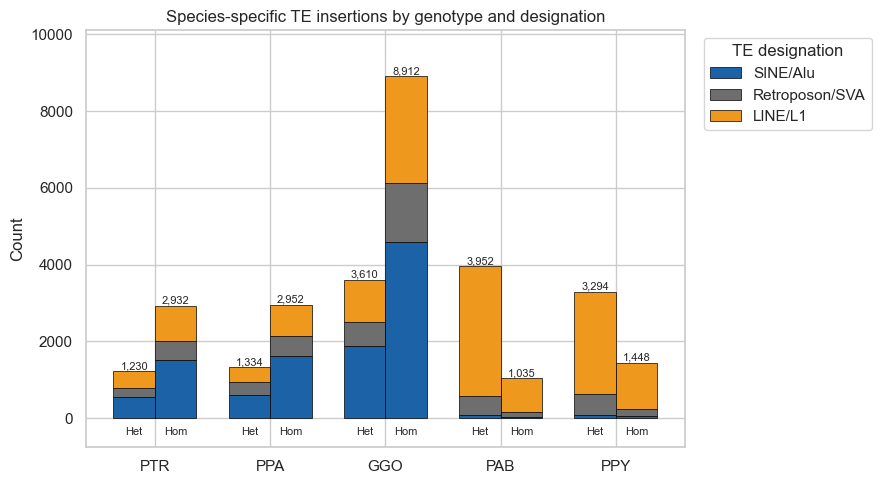

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

dfs = {
    "PPY": PPY_PAVDF_unfilteredSSonly,
    "PAB": PAB_PAVDF_unfilteredSSonly,
    "PTR": PTR_PAVDF_unfilteredSSonly,
    "GGO": GGO_PAVDF_unfilteredSSonly,
    "PPA": PPA_PAVDF_unfilteredSSonly,
}

speciesOrderList = ['PTR', 'PPA', 'GGO', 'PAB', 'PPY']

all_tes = ["SINE/Alu", "Retroposon/SVA", "LINE/L1"]

te_colors = {
    "SINE/Alu": "#1B62A6",
    "Retroposon/SVA": "#6E6E6E",
    "LINE/L1": "#EE981E"
}

fixed_order = ["Heterozygous", "Homozygous"]

# Combine all species into one dataframe in desired order
plot_dfs = []

for species in speciesOrderList:
    df = dfs[species]

    tmp = df.copy()
    tmp["species"] = species

    tmp["Fixed_Umbrella"] = (
        tmp["Fixed"]
        .astype(str)
        .str.upper()
        .map({
            "NO": "Heterozygous",
            "YES": "Homozygous"
        })
    )

    tmp["TE_Designation"] = tmp["TE_Designation"].astype(str)

    tmp = tmp.dropna(subset=["Fixed_Umbrella", "TE_Designation"])
    tmp = tmp[tmp["TE_Designation"].isin(all_tes)]

    plot_dfs.append(tmp)

plot_df = pd.concat(plot_dfs, ignore_index=True)

# Count by species, fixed umbrella, and TE class
count_df = (
    plot_df
    .groupby(["species", "Fixed_Umbrella", "TE_Designation"])
    .size()
    .reset_index(name="count")
)

# Fill missing combinations with 0
full_index = pd.MultiIndex.from_product(
    [speciesOrderList, fixed_order, all_tes],
    names=["species", "Fixed_Umbrella", "TE_Designation"]
)

count_df = (
    count_df
    .set_index(["species", "Fixed_Umbrella", "TE_Designation"])
    .reindex(full_index, fill_value=0)
    .reset_index()
)

# Plot side-by-side stacked bars
fig, ax = plt.subplots(figsize=(9, 5))

x = np.arange(len(speciesOrderList))
bar_width = 0.36

offsets = {
    "Heterozygous": -bar_width / 2,
    "Homozygous": bar_width / 2
}

for fixed in fixed_order:
    bottom = np.zeros(len(speciesOrderList))

    for te in all_tes:
        vals = []

        for species in speciesOrderList:
            val = count_df.loc[
                (count_df["species"] == species) &
                (count_df["Fixed_Umbrella"] == fixed) &
                (count_df["TE_Designation"] == te),
                "count"
            ].values[0]

            vals.append(val)

        vals = np.array(vals)

        ax.bar(
            x + offsets[fixed],
            vals,
            bar_width,
            bottom=bottom,
            color=te_colors[te],
            edgecolor="black",
            linewidth=0.5,
            label=te if fixed == fixed_order[0] else None
        )

        bottom += vals

    # Add total count above each bar
    for i, species in enumerate(speciesOrderList):
        total = count_df.loc[
            (count_df["species"] == species) &
            (count_df["Fixed_Umbrella"] == fixed),
            "count"
        ].sum()

        ax.text(
            x[i] + offsets[fixed],
            total,
            f"{total:,}",
            ha="center",
            va="bottom",
            fontsize=8
        )

# X-axis species labels
ax.set_xticks(x)
ax.set_xticklabels(speciesOrderList)

# Add Het/Hom labels under each grouped bar
ymax = ax.get_ylim()[1]
ax.set_ylim(-0.08 * ymax, ymax * 1.08)

for i, species in enumerate(speciesOrderList):
    ax.text(
        x[i] - bar_width / 2,
        -0.025 * ymax,
        "Het",
        ha="center",
        va="top",
        fontsize=8
    )

    ax.text(
        x[i] + bar_width / 2,
        -0.025 * ymax,
        "Hom",
        ha="center",
        va="top",
        fontsize=8
    )

ax.set_ylabel("Count")
ax.set_title("Species-specific TE insertions by genotype and designation")

ax.legend(
    title="TE designation",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()
plt.savefig("/Users/loftum/Desktop/PersonalProjects/TE_Leaves/Publication/2026_SexChromosome_Removal/deliverables/figures/species_specific_insertion_barSplit.pdf", format="pdf", bbox_inches="tight")
plt.savefig("/Users/loftum/Desktop/PersonalProjects/TE_Leaves/Publication/2026_SexChromosome_Removal/deliverables/figures/species_specific_insertion_barSplit.jpg", dpi=300, bbox_inches="tight")

plt.show()

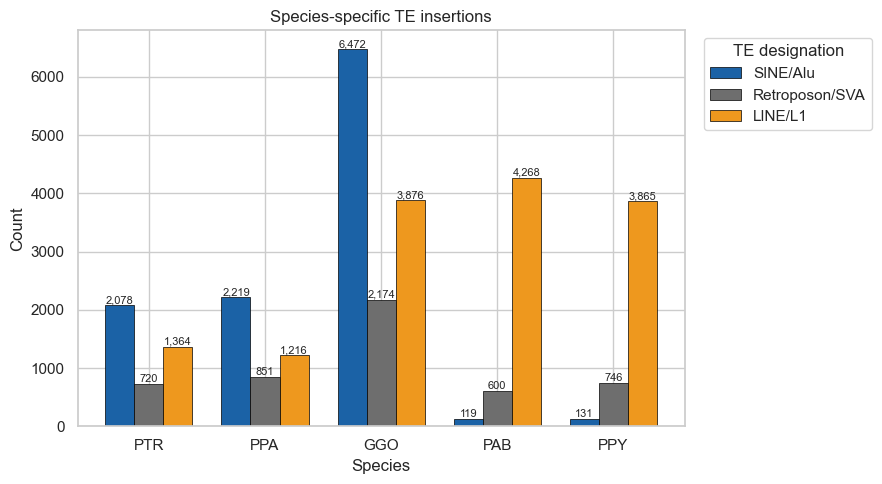

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

dfs = {
    "PPY": PPY_PAVDF_unfilteredSSonly,
    "PAB": PAB_PAVDF_unfilteredSSonly,
    "PTR": PTR_PAVDF_unfilteredSSonly,
    "GGO": GGO_PAVDF_unfilteredSSonly,
    "PPA": PPA_PAVDF_unfilteredSSonly,
}

species_order = ['PTR', 'PPA', 'GGO', 'PAB', 'PPY']

all_tes = ["SINE/Alu", "Retroposon/SVA", "LINE/L1"]

te_colors = {
    "SINE/Alu": "#1B62A6",
    "Retroposon/SVA": "#6E6E6E",
    "LINE/L1": "#EE981E"
}

# Combine all species into one dataframe in desired order
plot_dfs = []

for species in species_order:
    df = dfs[species]

    tmp = df.copy()
    tmp["species"] = species
    tmp["TE_Designation"] = tmp["TE_Designation"].astype(str)

    # Keep only the TE types you want
    tmp = tmp[tmp["TE_Designation"].isin(all_tes)]

    plot_dfs.append(tmp)

plot_df = pd.concat(plot_dfs, ignore_index=True)

# Count by species and TE type
count_df = (
    plot_df
    .groupby(["species", "TE_Designation"])
    .size()
    .reset_index(name="count")
)

# Fill missing species/TE combinations with 0
full_index = pd.MultiIndex.from_product(
    [species_order, all_tes],
    names=["species", "TE_Designation"]
)

count_df = (
    count_df
    .set_index(["species", "TE_Designation"])
    .reindex(full_index, fill_value=0)
    .reset_index()
)

# Plot grouped bars
fig, ax = plt.subplots(figsize=(9, 5))

x = np.arange(len(species_order))
bar_width = 0.25

offsets = np.linspace(
    -bar_width,
    bar_width,
    len(all_tes)
)

for offset, te in zip(offsets, all_tes):
    vals = []

    for species in species_order:
        val = count_df.loc[
            (count_df["species"] == species) &
            (count_df["TE_Designation"] == te),
            "count"
        ].values[0]

        vals.append(val)

    bars = ax.bar(
        x + offset,
        vals,
        width=bar_width,
        color=te_colors[te],
        edgecolor="black",
        linewidth=0.5,
        label=te
    )

    # Add count labels above each bar
    for bar in bars:
        height = bar.get_height()

        ax.text(
            bar.get_x() + bar.get_width() / 2,
            height,
            f"{int(height):,}",
            ha="center",
            va="bottom",
            fontsize=8,
            rotation=0
        )

ax.set_xticks(x)
ax.set_xticklabels(species_order)

ax.set_ylabel("Count")
ax.set_xlabel("Species")
ax.set_title("Species-specific TE insertions")

ax.legend(
    title="TE designation",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()
plt.savefig("/Users/loftum/Desktop/PersonalProjects/TE_Leaves/Publication/2026_SexChromosome_Removal/deliverables/figures/species_specific_insertion_combinedBar.pdf", format="pdf", bbox_inches="tight")
plt.savefig("/Users/loftum/Desktop/PersonalProjects/TE_Leaves/Publication/2026_SexChromosome_Removal/deliverables/figures/species_specific_insertion_combinedBar.jpg", dpi=300, bbox_inches="tight")

plt.show()

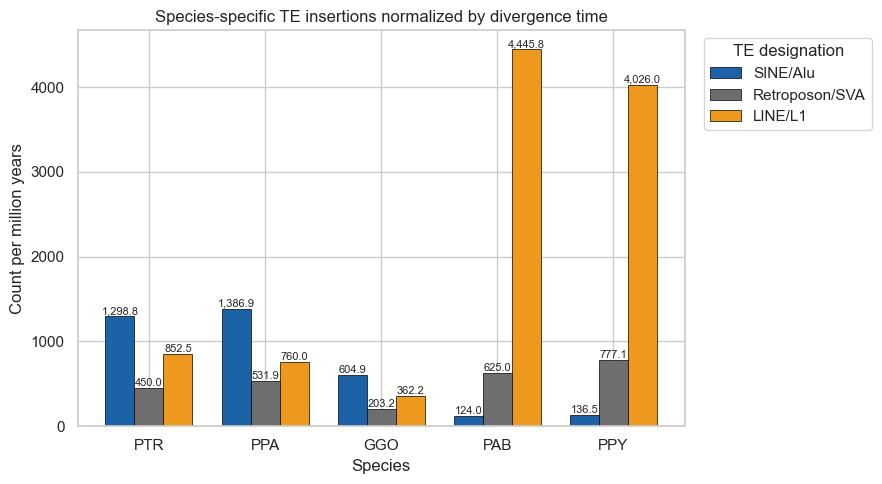

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

dfs = {
    "PPY": PPY_PAVDF_unfilteredSSonly,
    "PAB": PAB_PAVDF_unfilteredSSonly,
    "PTR": PTR_PAVDF_unfilteredSSonly,
    "GGO": GGO_PAVDF_unfilteredSSonly,
    "PPA": PPA_PAVDF_unfilteredSSonly,
}

divergentMYR = {
    "HG002": 6.2,
    "hs1": 6.2,
    "PPA": 1.6,
    "PTR": 1.6,
    "GGO": 10.7,
    "PPY": 0.96,
    "PAB": 0.96
}

species_order = ['PTR', 'PPA', 'GGO', 'PAB', 'PPY']

all_tes = ["SINE/Alu", "Retroposon/SVA", "LINE/L1"]

te_colors = {
    "SINE/Alu": "#1B62A6",
    "Retroposon/SVA": "#6E6E6E",
    "LINE/L1": "#EE981E"
}

# Combine all species into one dataframe in desired order
plot_dfs = []

for species in species_order:
    df = dfs[species]

    tmp = df.copy()
    tmp["species"] = species
    tmp["TE_Designation"] = tmp["TE_Designation"].astype(str)

    # Keep only the TE types you want
    tmp = tmp[tmp["TE_Designation"].isin(all_tes)]

    plot_dfs.append(tmp)

plot_df = pd.concat(plot_dfs, ignore_index=True)

# Count by species and TE type
count_df = (
    plot_df
    .groupby(["species", "TE_Designation"])
    .size()
    .reset_index(name="count")
)

# Fill missing species/TE combinations with 0
full_index = pd.MultiIndex.from_product(
    [species_order, all_tes],
    names=["species", "TE_Designation"]
)

count_df = (
    count_df
    .set_index(["species", "TE_Designation"])
    .reindex(full_index, fill_value=0)
    .reset_index()
)

# Add MYR normalization
count_df["MYR"] = count_df["species"].map(divergentMYR)
count_df["count_per_MYR"] = count_df["count"] / count_df["MYR"]

# Plot grouped bars
fig, ax = plt.subplots(figsize=(9, 5))

x = np.arange(len(species_order))
bar_width = 0.25

offsets = np.linspace(
    -bar_width,
    bar_width,
    len(all_tes)
)

for offset, te in zip(offsets, all_tes):
    vals = []

    for species in species_order:
        val = count_df.loc[
            (count_df["species"] == species) &
            (count_df["TE_Designation"] == te),
            "count_per_MYR"
        ].values[0]

        vals.append(val)

    bars = ax.bar(
        x + offset,
        vals,
        width=bar_width,
        color=te_colors[te],
        edgecolor="black",
        linewidth=0.5,
        label=te
    )

    # Add normalized count labels above each bar
    for bar in bars:
        height = bar.get_height()

        ax.text(
            bar.get_x() + bar.get_width() / 2,
            height,
            f"{height:,.1f}",
            ha="center",
            va="bottom",
            fontsize=8,
            rotation=0
        )

ax.set_xticks(x)
ax.set_xticklabels(species_order)

ax.set_ylabel("Count per million years")
ax.set_xlabel("Species")
ax.set_title("Species-specific TE insertions normalized by divergence time")

ax.legend(
    title="TE designation",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()
plt.savefig("/Users/loftum/Desktop/PersonalProjects/TE_Leaves/Publication/2026_SexChromosome_Removal/deliverables/figures/species_specific_insertion_combinedBar_normalized.pdf", format="pdf", bbox_inches="tight")
plt.savefig("/Users/loftum/Desktop/PersonalProjects/TE_Leaves/Publication/2026_SexChromosome_Removal/deliverables/figures/species_specific_insertion_combinedBar_normalized.jpg", dpi=300, bbox_inches="tight")

plt.show()

In [12]:
## Original CACTUS callset YOO 2025 do not change these
sexChromosomes = ['CM054458.2',
 'CM054483.2',
 'CM054534.2',
 'CM054581.2',
 'CM054654.2',
 'CM054703.2',
 'CM055470.2',
 'CM055496.2',
 'CM054457.2',
 'CM054507.2',
 'CM054533.2',
 'CM054605.2',
 'CM054653.2',
 'CM054702.2',
 'CM055469.2',
 'CM055495.2']

PPY_cactus = pd.read_csv("/Users/loftum/Desktop/PersonalProjects/TE_Leaves/Publication/2026_SexChromosome_Removal/Cactus/PonPyg_Final_07-05-2024.csv")
PAB_cactus = pd.read_csv("/Users/loftum/Desktop/PersonalProjects/TE_Leaves/Publication/2026_SexChromosome_Removal/Cactus/PonAbe_Final_07-05-2024.csv")
GGO_cactus = pd.read_csv("/Users/loftum/Desktop/PersonalProjects/TE_Leaves/Publication/2026_SexChromosome_Removal/Cactus/GorGor_Final_07-05-2024.csv")
PTR_cactus = pd.read_csv("/Users/loftum/Desktop/PersonalProjects/TE_Leaves/Publication/2026_SexChromosome_Removal/Cactus/PanTro_Final_07-05-2024.csv")
PPA_cactus = pd.read_csv("/Users/loftum/Desktop/PersonalProjects/TE_Leaves/Publication/2026_SexChromosome_Removal/Cactus/PanPan_Final_07-05-2024.csv")

PPY_cactus_sexFiltered = PPY_cactus[~PPY_cactus['CHROM'].isin(sexChromosomes)].copy()
PAB_cactus_sexFiltered = PAB_cactus[~PAB_cactus['CHROM'].isin(sexChromosomes)].copy()
GGO_cactus_sexFiltered = GGO_cactus[~GGO_cactus['CHROM'].isin(sexChromosomes)].copy()
PTR_cactus_sexFiltered = PTR_cactus[~PTR_cactus['CHROM'].isin(sexChromosomes)].copy()
PPA_cactus_sexFiltered = PPA_cactus[~PPA_cactus['CHROM'].isin(sexChromosomes)].copy()

PPY_cactus_sexFiltered_HET = PPY_cactus_sexFiltered[(PPY_cactus_sexFiltered['Fixed']=='NO')].copy()
PAB_cactus_sexFiltered_HET = PAB_cactus_sexFiltered[(PAB_cactus_sexFiltered['Fixed']=='NO')].copy()
GGO_cactus_sexFiltered_HET = GGO_cactus_sexFiltered[(GGO_cactus_sexFiltered['Fixed']=='NO')].copy()
PTR_cactus_sexFiltered_HET = PTR_cactus_sexFiltered[(PTR_cactus_sexFiltered['Fixed']=='NO')].copy()
PPA_cactus_sexFiltered_HET = PPA_cactus_sexFiltered[(PPA_cactus_sexFiltered['Fixed']=='NO')].copy()

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

cactusCallsets = [
    PPY_cactus_sexFiltered,
    PAB_cactus_sexFiltered,
    GGO_cactus_sexFiltered,
    PTR_cactus_sexFiltered,
    PPA_cactus_sexFiltered
]

pavCallsets = [
    PPY_PAVDF_sexFiltered,
    PAB_PAVDF_sexFiltered,
    GGO_PAVDF_sexFiltered,
    PTR_PAVDF_sexFiltered,
    PPA_PAVDF_sexFiltered
]
species = ["PPY", "PAB", "GGO", "PTR", "PPA"]

row_counts_nosex_all = pd.DataFrame({
    "species": species,
    "cactus_rows_nosex_all": [len(df) for df in cactusCallsets],
    "pav_rows_nosex_all": [len(df) for df in pavCallsets]
})

row_counts_nosex_all["difference_cactus_minus_pav_nosex_all"] = (
    row_counts_nosex_all["cactus_rows_nosex_all"] - row_counts_nosex_all["pav_rows_nosex_all"]
)

row_counts_nosex_all.set_index("species", inplace=True)

## Compare how many additional heterozygous species specific calls are gained through PAV second haplotype

In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

cactusCallsets = [
    PPY_cactus_sexFiltered_HET,
    PAB_cactus_sexFiltered_HET,
    GGO_cactus_sexFiltered_HET,
    PTR_cactus_sexFiltered_HET,
    PPA_cactus_sexFiltered_HET
]

pavCallsets = [
    PPY_Het_noSex_PAVDF,
    PAB_Het_noSex_PAVDF,
    GGO_Het_noSex_PAVDF,
    PTR_Het_noSex_PAVDF,
    PPA_Het_noSex_PAVDF
]

species = ["PTR", "PPA", "GGO", "PAB", "PPY"]

row_counts_noSex_Het = pd.DataFrame({
    "species": species,
    "cactus_rows_noSex_het": [len(df) for df in cactusCallsets],
    "pav_rows_noSex_het": [len(df) for df in pavCallsets]
})

row_counts_noSex_Het["difference_cactus_minus_pav_noSex_het"] = (
    row_counts_noSex_Het["cactus_rows_noSex_het"] - row_counts_noSex_Het["pav_rows_noSex_het"]
)

row_counts_noSex_Het.set_index("species", inplace=True)

In [15]:
row_counts_noSex_Het

,cactus_rows_noSex_het,pav_rows_noSex_het,difference_cactus_minus_pav_noSex_het
species,,,
PTR,2041,3033,-992
PPA,2315,3686,-1371
GGO,2086,2950,-864
PAB,676,1043,-367
PPY,841,1181,-340


In [16]:
sum(abs(row_counts_noSex_Het['difference_cactus_minus_pav_noSex_het']))

3934

In [17]:
#merged_cactusvsPAV_noSex_df = row_counts_nosex_all.join(row_counts_noSex_Het)

In [18]:
#divegentMYR={'HG002':6.2,'hs1':6.2,'PPA':1.6,'PTR':1.6,'GGO':10.7,'PPY':.96, 'PAB':.96}
#merged_cactusvsPAV_noSex_df['Normalized_pav_noSex_all'] = [int(merged_cactusvsPAV_noSex_df.at[x,'pav_rows_nosex_all'])/divegentMYR[x] for x in merged_cactusvsPAV_noSex_df.index]
#merged_cactusvsPAV_noSex_df['Normalized_cactus_noSex_all'] = [int(merged_cactusvsPAV_noSex_df.at[x,'cactus_rows_nosex_all'])/divegentMYR[x] for x in merged_cactusvsPAV_noSex_df.index]
#merged_cactusvsPAV_noSex_df['Normalized_pav_noSex_het'] = [int(merged_cactusvsPAV_noSex_df.at[x,'pav_rows_noSex_het'])/divegentMYR[x] for x in merged_cactusvsPAV_noSex_df.index]
#merged_cactusvsPAV_noSex_df['Normalized_cactus_noSex_het'] = [int(merged_cactusvsPAV_noSex_df.at[x,'cactus_rows_noSex_het'])/divegentMYR[x] for x in merged_cactusvsPAV_noSex_df.index]

In [19]:
#merged_cactusvsPAV_noSex_df['pav_rows_noSex_homo'] = [int(merged_cactusvsPAV_noSex_df.at[x,'pav_rows_nosex_all'])-int(merged_cactusvsPAV_noSex_df.at[x,'pav_rows_noSex_het']) for x in merged_cactusvsPAV_noSex_df.index]
#merged_cactusvsPAV_noSex_df['cactus_rows_noSex_homo']= [int(merged_cactusvsPAV_noSex_df.at[x,'cactus_rows_nosex_all'])-int(merged_cactusvsPAV_noSex_df.at[x,'cactus_rows_noSex_het']) for x in merged_cactusvsPAV_noSex_df.index]#

#merged_cactusvsPAV_noSex_df['Normalized_pav_noSex_homo'] = [int(merged_cactusvsPAV_noSex_df.at[x,'pav_rows_noSex_homo'])/divegentMYR[x] for x in merged_cactusvsPAV_noSex_df.index]
#merged_cactusvsPAV_noSex_df['Normalized_cactus_noSex_homo'] = [int(merged_cactusvsPAV_noSex_df.at[x,'cactus_rows_noSex_homo'])/divegentMYR[x] for x in merged_cactusvsPAV_noSex_df.index]

In [20]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

species_order = ["PTR", "PPA", "GGO", "PAB", "PPY"]

divergentMYR = {
    "HG002": 6.2,
    "hs1": 6.2,
    "PPA": 1.6,
    "PTR": 1.6,
    "GGO": 10.7,
    "PPY": 0.96,
    "PAB": 0.96
}

cactus_all = {
    "PPY": PPY_cactus_sexFiltered,
    "PAB": PAB_cactus_sexFiltered,
    "PTR": PTR_cactus_sexFiltered,
    "GGO": GGO_cactus_sexFiltered,
    "PPA": PPA_cactus_sexFiltered,
}

cactus_het = {
    "PPY": PPY_cactus_sexFiltered_HET,
    "PAB": PAB_cactus_sexFiltered_HET,
    "PTR": PTR_cactus_sexFiltered_HET,
    "GGO": GGO_cactus_sexFiltered_HET,
    "PPA": PPA_cactus_sexFiltered_HET,
}

pav_all = {
    "PPY": PPY_PAVDF_sexFiltered,
    "PAB": PAB_PAVDF_sexFiltered,
    "PTR": PTR_PAVDF_sexFiltered,
    "GGO": GGO_PAVDF_sexFiltered,
    "PPA": PPA_PAVDF_sexFiltered,
}

pav_het = {
    "PPY": PPY_Het_noSex_PAVDF,
    "PAB": PAB_Het_noSex_PAVDF,
    "PTR": PTR_Het_noSex_PAVDF,
    "GGO": GGO_Het_noSex_PAVDF,
    "PPA": PPA_Het_noSex_PAVDF,
}

rows = []

for sp in species_order:
    pav_all_n = len(pav_all[sp])
    cactus_all_n = len(cactus_all[sp])

    pav_het_n = len(pav_het[sp])
    cactus_het_n = len(cactus_het[sp])

    pav_homo_n = pav_all_n - pav_het_n
    cactus_homo_n = cactus_all_n - cactus_het_n

    rows.append({
        "species": sp,

        "pav_rows_nosex_all": pav_all_n,
        "cactus_rows_nosex_all": cactus_all_n,

        "pav_rows_noSex_het": pav_het_n,
        "cactus_rows_noSex_het": cactus_het_n,

        "pav_rows_noSex_homo": pav_homo_n,
        "cactus_rows_noSex_homo": cactus_homo_n,

        "difference_cactus_minus_pav_nosex_all": cactus_all_n - pav_all_n,
        "difference_cactus_minus_pav_noSex_het": cactus_het_n - pav_het_n,
        "difference_cactus_minus_pav_noSex_homo": cactus_homo_n - pav_homo_n,
    })

merged_cactusvsPAV_noSex_df = pd.DataFrame(rows).set_index("species")

# Add MYR normalization
merged_cactusvsPAV_noSex_df["MYR"] = merged_cactusvsPAV_noSex_df.index.map(divergentMYR)

for col in [
    "pav_rows_nosex_all",
    "cactus_rows_nosex_all",
    "pav_rows_noSex_het",
    "cactus_rows_noSex_het",
    "pav_rows_noSex_homo",
    "cactus_rows_noSex_homo",
]:
    merged_cactusvsPAV_noSex_df[f"Normalized_{col}"] = (
        merged_cactusvsPAV_noSex_df[col] /
        merged_cactusvsPAV_noSex_df["MYR"]
    )

merged_cactusvsPAV_noSex_df

,pav_rows_nosex_all,cactus_rows_nosex_all,pav_rows_noSex_het,cactus_rows_noSex_het,pav_rows_noSex_homo,cactus_rows_noSex_homo,difference_cactus_minus_pav_nosex_all,difference_cactus_minus_pav_noSex_het,difference_cactus_minus_pav_noSex_homo,MYR,Normalized_pav_rows_nosex_all,Normalized_cactus_rows_nosex_all,Normalized_pav_rows_noSex_het,Normalized_cactus_rows_noSex_het,Normalized_pav_rows_noSex_homo,Normalized_cactus_rows_noSex_homo
species,,,,,,,,,,,,,,,,
PTR,3975,3618,1043,676,2932,2942,-357,-367,10,1.60,2484.375000,2261.250000,651.875000,422.500000,1832.500000,1838.750000
PPA,4133,3780,1181,841,2952,2939,-353,-340,-13,1.60,2583.125000,2362.500000,738.125000,525.625000,1845.000000,1836.875000
GGO,11862,10970,2950,2086,8912,8884,-892,-864,-28,10.70,1108.598131,1025.233645,275.700935,194.953271,832.897196,830.280374
PAB,4721,3403,3686,2315,1035,1088,-1318,-1371,53,0.96,4917.708333,3544.791667,3839.583333,2411.458333,1078.125000,1133.333333
PPY,4481,3605,3033,2041,1448,1564,-876,-992,116,0.96,4667.708333,3755.208333,3159.375000,2126.041667,1508.333333,1629.166667


In [32]:
from scipy.stats import pearsonr

r, p_value = pearsonr(homo_df["PAV"], homo_df["Cactus"])

print(f"Pearson r = {r:.4f}")
print(f"P-value = {p_value:.4g}")

Pearson r = 0.9927
P-value = 0.0007404


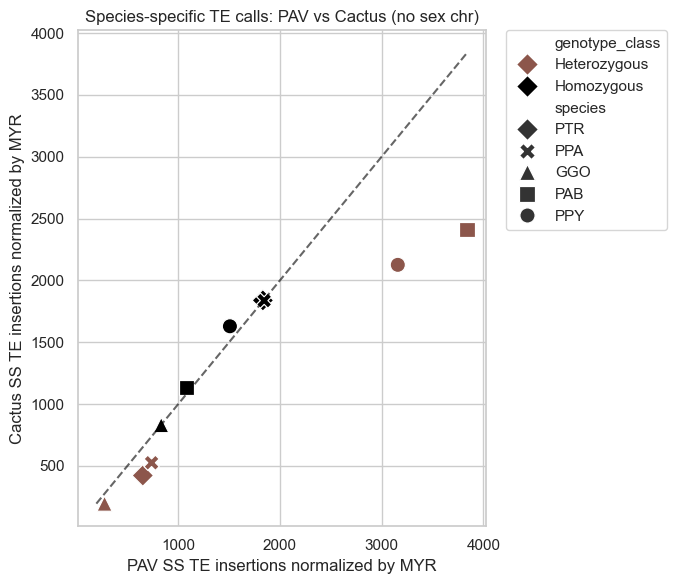

In [21]:
sns.set_theme(style="whitegrid")

genotype_colors = {
    "Homozygous": "black",
    "Heterozygous": "#8C564B"
}

row_counts = merged_cactusvsPAV_noSex_df.reset_index()

homo_df = row_counts[[
    "species",
    "Normalized_pav_rows_noSex_homo",
    "Normalized_cactus_rows_noSex_homo"
]].copy()

homo_df = homo_df.rename(columns={
    "Normalized_pav_rows_noSex_homo": "PAV",
    "Normalized_cactus_rows_noSex_homo": "Cactus"
})

homo_df["genotype_class"] = "Homozygous"


het_df = row_counts[[
    "species",
    "Normalized_pav_rows_noSex_het",
    "Normalized_cactus_rows_noSex_het"
]].copy()

het_df = het_df.rename(columns={
    "Normalized_pav_rows_noSex_het": "PAV",
    "Normalized_cactus_rows_noSex_het": "Cactus"
})

het_df["genotype_class"] = "Heterozygous"

plot_df = pd.concat([homo_df, het_df], ignore_index=True)

plot_df["species"] = pd.Categorical(
    plot_df["species"],
    categories=species_order,
    ordered=True
)

plot_df["genotype_class"] = pd.Categorical(
    plot_df["genotype_class"],
    categories=["Heterozygous", "Homozygous"],
    ordered=True
)

markers = {
    "PPY": "o",
    "PAB": "s",
    "GGO": "^",
    "PTR": "D",
    "PPA": "X"
}

plt.figure(figsize=(7, 6))

ax = sns.scatterplot(
    data=plot_df,
    x="PAV",
    y="Cactus",
    hue="genotype_class",
    hue_order=["Heterozygous", "Homozygous"],
    palette=genotype_colors,
    style="species",
    style_order=species_order,
    markers=markers,
    s=120
)

min_val = min(plot_df["PAV"].min(), plot_df["Cactus"].min())
max_val = max(plot_df["PAV"].max(), plot_df["Cactus"].max())

ax.plot(
    [min_val, max_val],
    [min_val, max_val],
    linestyle="--",
    color="black",
    alpha=0.6
)

ax.set_xlabel("PAV SS TE insertions normalized by MYR")
ax.set_ylabel("Cactus SS TE insertions normalized by MYR")
ax.set_title("Species-specific TE calls: PAV vs Cactus (no sex chr)")

ax.legend(
    title="",
    bbox_to_anchor=(1.05, 1),
    loc="upper left",
    borderaxespad=0
)

plt.tight_layout()
plt.savefig("/Users/loftum/Desktop/PersonalProjects/TE_Leaves/Publication/2026_SexChromosome_Removal/deliverables/figures/species_specific_insertion_pav_vs_cactus.pdf", format="pdf", bbox_inches="tight")
plt.savefig("/Users/loftum/Desktop/PersonalProjects/TE_Leaves/Publication/2026_SexChromosome_Removal/deliverables/figures/species_specific_insertion_pav_vs_cactus.jpg", dpi=300, bbox_inches="tight")

plt.show()

## Look at Polymorphic SS + LS calls

In [22]:
import pandas as pd

pavCallsets = [
    PPY_PAVDF_SSsexFiltered,
    PAB_PAVDF_SSsexFiltered,
    GGO_PAVDF_SSsexFiltered,
    PTR_PAVDF_SSsexFiltered,
    PPA_PAVDF_SSsexFiltered
]

species = ["PPY", "PAB", "GGO", "PTR", "PPA"]
te_types = set(PPA_PAVDF_sexFiltered["TE_Designation"].dropna())

rows = []

for sp, pav_df in zip(species, pavCallsets):
    for te in te_types:
        pav_count = (pav_df["TE_Designation"] == te).sum()

        rows.append({
            "species": sp,
            "TE_Designation": te,
            "polymorphic_pav_SS_LS": pav_count,
        })

row_counts_polymorphic_PAV_TE = pd.DataFrame(rows)

row_counts_polymorphic_PAV_TE = row_counts_polymorphic_PAV_TE.sort_values(
    ["TE_Designation", "species"]
)

row_counts_polymorphic_PAV_TE

,species,TE_Designation,polymorphic_pav_SS_LS
8,GGO,LINE/L1,786
5,PAB,LINE/L1,4027
14,PPA,LINE/L1,356
2,PPY,LINE/L1,2559
11,PTR,LINE/L1,374
7,GGO,Retroposon/SVA,549
4,PAB,Retroposon/SVA,543
13,PPA,Retroposon/SVA,349
1,PPY,Retroposon/SVA,550
10,PTR,Retroposon/SVA,211


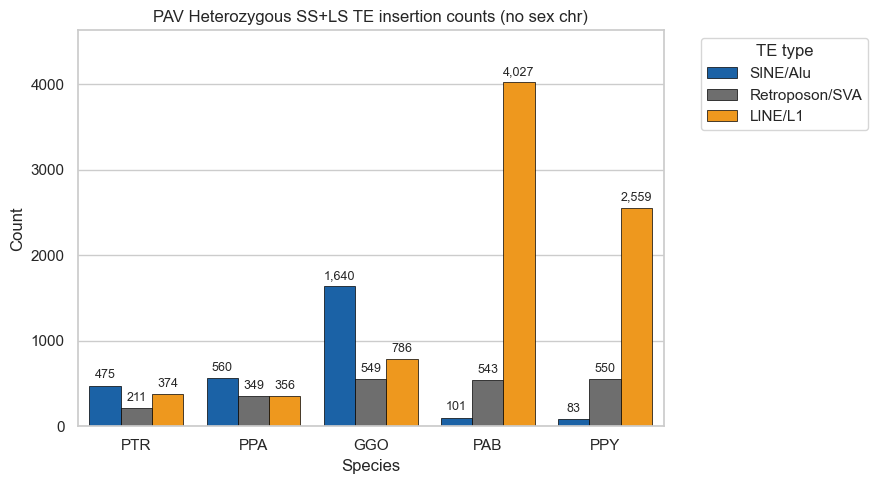

In [23]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

plot_df = row_counts_polymorphic_PAV_TE.copy()

# Species order used in the other plots
species_order = ["PTR", "PPA", "GGO", "PAB", "PPY"]

# TE order and colors used in the other plots
te_order = ["SINE/Alu", "Retroposon/SVA", "LINE/L1"]

te_colors = {
    "SINE/Alu": "#1B62A6",
    "Retroposon/SVA": "#6E6E6E",
    "LINE/L1": "#EE981E"
}

# Clean columns and enforce plotting order
plot_df["species"] = pd.Categorical(
    plot_df["species"],
    categories=species_order,
    ordered=True
)

plot_df["TE_Designation"] = pd.Categorical(
    plot_df["TE_Designation"],
    categories=te_order,
    ordered=True
)

plot_df = plot_df[plot_df["TE_Designation"].isin(te_order)].copy()

plt.figure(figsize=(9, 5))

ax = sns.barplot(
    data=plot_df,
    x="species",
    y="polymorphic_pav_SS_LS",
    hue="TE_Designation",
    order=species_order,
    hue_order=te_order,
    palette=te_colors,
    edgecolor="black",
    linewidth=0.5,
    saturation=1
)

ax.set_xlabel("Species")
ax.set_ylabel("Count")
ax.set_title("PAV Heterozygous SS+LS TE insertion counts (no sex chr)")

ax.legend(
    title="TE type",
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

# Add count above each individual TE-designation bar
for container in ax.containers:
    labels = [
        f"{int(bar.get_height()):,}" if bar.get_height() > 0 else ""
        for bar in container
    ]

    ax.bar_label(
        container,
        labels=labels,
        padding=3,
        fontsize=9,
        fontweight="regular"
    )

# Add headroom so labels do not get clipped
ymax = max(
    bar.get_height()
    for container in ax.containers
    for bar in container
)

ax.set_ylim(0, ymax * 1.15)

plt.tight_layout()
plt.savefig("/Users/loftum/Desktop/PersonalProjects/TE_Leaves/Publication/2026_SexChromosome_Removal/deliverables/figures/species_and_lineage_heterozygous_insertions.pdf", format="pdf", bbox_inches="tight")
plt.savefig("/Users/loftum/Desktop/PersonalProjects/TE_Leaves/Publication/2026_SexChromosome_Removal/deliverables/figures/species_and_lineage_heterozygous_insertions.jpg", dpi=300, bbox_inches="tight")

plt.show()

In [24]:
L1_polymorphic_all = row_counts_polymorphic_PAV_TE[row_counts_polymorphic_PAV_TE['TE_Designation']=='LINE/L1'].set_index('species').copy()

In [25]:
L1_polymorphic_all['polymorphic_FL_L1']=0

## Polymorphic L1s with BOTH ORFS intact

In [26]:
import pandas as pd
import collections

pavCallsets = [
    PPY_PAVDF_SSsexFiltered,
    PAB_PAVDF_SSsexFiltered,
    GGO_PAVDF_SSsexFiltered,
    PTR_PAVDF_SSsexFiltered,
    PPA_PAVDF_SSsexFiltered
]

species = ["PPY", "PAB", "GGO", "PTR", "PPA"]

rows = []

for sp, pav_df in zip(species, pavCallsets):
    pav_df = pav_df.copy()

    pav_df["Sequence_Length"] = pd.to_numeric(
        pav_df["Sequence_Length"],
        errors="coerce"
    )

    tempPAV = pav_df[
        (pav_df["TE_Designation"] == "LINE/L1") &
        (pav_df["Sequence_Length"] >= 5900)
    ].copy()
    
    L1_polymorphic_all.at[sp, 'polymorphic_FL_L1'] = len(tempPAV)
    

    countORFs = collections.Counter(tempPAV["L1_ORF_Stats"])

    for key, value in countORFs.items():
        rows.append({
            "species": sp,
            "Element": "FL_LINE/L1",
            "ORF_Status": key,
            "Total_FL_LINEs": value,
            "Proportion_FL_LINEs": value/len(tempPAV),
        })

row_counts_FL_L1_ORF = pd.DataFrame(rows)

row_counts_FL_L1_ORF = row_counts_FL_L1_ORF.sort_values(
    ["ORF_Status", "species"]
)

row_counts_FL_L1_ORF

,species,Element,ORF_Status,Total_FL_LINEs,Proportion_FL_LINEs
10,GGO,FL_LINE/L1,BOTH,185,0.642361
5,PAB,FL_LINE/L1,BOTH,636,0.558385
20,PPA,FL_LINE/L1,BOTH,70,0.736842
1,PPY,FL_LINE/L1,BOTH,503,0.652399
15,PTR,FL_LINE/L1,BOTH,40,0.579710
13,GGO,FL_LINE/L1,NONE,19,0.065972
6,PAB,FL_LINE/L1,NONE,144,0.126427
22,PPA,FL_LINE/L1,NONE,6,0.063158
3,PPY,FL_LINE/L1,NONE,54,0.070039
18,PTR,FL_LINE/L1,NONE,4,0.057971


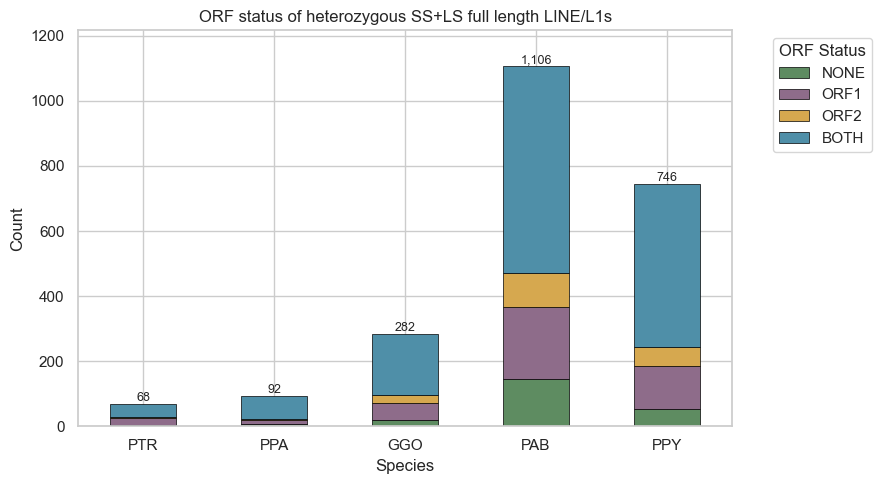

In [27]:
import pandas as pd
import matplotlib.pyplot as plt

# Species order used in the other plots
species_order = ["PTR", "PPA", "GGO", "PAB", "PPY"]

# ORF order
orf_order = ["NONE", "ORF1", "ORF2", "BOTH"]

# Choose ORF colors here
orf_colors = {
    "NONE": "#5E8C61",   # muted green
    "ORF1": "#8E6C8A",   # muted purple
    "ORF2": "#D6A84F",   # muted gold
    "BOTH": "#4F8FA8"    # muted teal-blue
}

plot_pivot = (
    row_counts_FL_L1_ORF
    .pivot(index="species", columns="ORF_Status", values="Total_FL_LINEs")
    .fillna(0)
)

# Reorder species rows and ORF columns
plot_pivot = plot_pivot.reindex(index=species_order)

plot_pivot = plot_pivot.reindex(
    columns=[c for c in orf_order if c in plot_pivot.columns],
    fill_value=0
)

# Make color list match plotted columns
plot_colors = [orf_colors[c] for c in plot_pivot.columns]

ax = plot_pivot.plot(
    kind="bar",
    stacked=True,
    figsize=(9, 5),
    width=0.5,
    color=plot_colors,
    edgecolor="black",
        linewidth=0.5,
)

ax.set_xlabel("Species")
ax.set_ylabel("Count")
ax.set_title("ORF status of heterozygous SS+LS full length LINE/L1s")

ax.set_xticklabels(species_order, rotation=0)

ax.legend(
    title="ORF Status",
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

# Add total LINE counts above each stacked bar
totals = plot_pivot.sum(axis=1)

for i, total in enumerate(totals):
    ax.text(
        i,
        total,
        f"{int(total):,}",
        ha="center",
        va="bottom",
        fontsize=9,
        fontweight="regular"
    )

ax.set_ylim(0, totals.max() * 1.10)

plt.tight_layout()
plt.savefig("/Users/loftum/Desktop/PersonalProjects/TE_Leaves/Publication/2026_SexChromosome_Removal/deliverables/figures/species_and_lineage_heterozygous_full_length_LINE_ORF_status.pdf", format="pdf", bbox_inches="tight")
plt.savefig("/Users/loftum/Desktop/PersonalProjects/TE_Leaves/Publication/2026_SexChromosome_Removal/deliverables/figures/sspecies_and_lineage_heterozygous_full_length_LINE_ORF_status.jpg", dpi=300, bbox_inches="tight")
plt.show()

In [28]:
#BOTH ORF INTACT ONLY FL Polymorphic LINES 
flL1Poly = row_counts_FL_L1_ORF[row_counts_FL_L1_ORF['ORF_Status']=='BOTH'].set_index('species').copy()

In [29]:
flL1Poly

,Element,ORF_Status,Total_FL_LINEs,Proportion_FL_LINEs
species,,,,
GGO,FL_LINE/L1,BOTH,185,0.642361
PAB,FL_LINE/L1,BOTH,636,0.558385
PPA,FL_LINE/L1,BOTH,70,0.736842
PPY,FL_LINE/L1,BOTH,503,0.652399
PTR,FL_LINE/L1,BOTH,40,0.579710


In [30]:
orangutans = ['PAB', 'PPY']
for species in orangutans:
    for row in flL1Poly.index:
        if row in orangutans:
            continue
        else:
            print(species, row)
            print(flL1Poly.at[species,'Total_FL_LINEs']/flL1Poly.at[row,'Total_FL_LINEs'])
    print('\n')

PAB GGO
3.437837837837838
PAB PPA
9.085714285714285
PAB PTR
15.9


PPY GGO
2.718918918918919
PPY PPA
7.185714285714286
PPY PTR
12.575


